# 11-2절 연습 문제 풀이

DCGAN을 다루는 [연습 문제 11-5] ~ [연습 문제 11-9]의 풀이다.

본문 예제(`11-02_example.ipynb`)의 데이터, 생성자·판별자, 학습 함수를 그대로 사용한다.


## 공통 준비

In [1]:

import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

viz.configure(save_grayscale=False)
common.set_korean_plot_env()

SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


In [2]:

# Fashion-MNIST를 [-1, 1] 범위로 정규화해 로드(본문 예제와 동일)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

data_root = '../../download'
train_set = datasets.FashionMNIST(root=data_root, train=True, download=True,
                                  transform=transform)
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
print(f'훈련 샘플 수: {len(train_set):,}')
print('클래스:', train_set.classes)

훈련 샘플 수: 60,000
클래스: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:

# 생성자와 판별자([코드 11-7], [코드 11-8])
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim
        self.fc_z_to_fmap = nn.Sequential(
            nn.Linear(latent_dim, 256 * 7 * 7),
            nn.BatchNorm1d(256 * 7 * 7),
            nn.ReLU(),
        )
        self.gen_conv = nn.Sequential(                # (256, 7, 7) -> (1, 28, 28)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        h = self.fc_z_to_fmap(z)
        h = h.view(h.size(0), 256, 7, 7)
        return self.gen_conv(h)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.disc_conv = nn.Sequential(               # (1, 28, 28) -> (128, 7, 7)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.fc(self.disc_conv(x))


def weights_init(m):
    """[코드 11-9]의 가중치 초기화"""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [4]:

# 학습 함수([코드 11-11])와 학습 루프
LATENT_DIM = 100
LR = 2e-4
EPOCHS = 20
criterion = nn.BCELoss()


def train_epoch(G, D, loader, optim_g, optim_d, criterion, latent_dim, device,
                detach_in_d=True, detach_in_g=False):
    """본문 [코드 11-11]에 detach 위치를 바꿀 수 있는 인자를 더했다."""
    G.train()
    D.train()
    total_loss_d = total_loss_g = 0.0
    total_samples = 0
    for real_images, _ in loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ① 판별자 학습
        optim_d.zero_grad()
        loss_d_real = criterion(D(real_images), real_labels)
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = G(z)
        d_input = fake_images.detach() if detach_in_d else fake_images
        loss_d_fake = criterion(D(d_input), fake_labels)
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optim_d.step()

        # ② 생성자 학습
        optim_g.zero_grad()
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = G(z)
        g_input = fake_images.detach() if detach_in_g else fake_images
        loss_g = criterion(D(g_input), real_labels)
        loss_g.backward()
        optim_g.step()

        total_loss_d += loss_d.item() * batch_size
        total_loss_g += loss_g.item() * batch_size
        total_samples += batch_size
    return total_loss_d / total_samples, total_loss_g / total_samples


def train_gan(G, D, loader, latent_dim=LATENT_DIM, epochs=EPOCHS, lr=LR,
              name='', detach_in_d=True, detach_in_g=False, verbose_rows=10,
              train_fn=None):
    G.apply(weights_init)
    D.apply(weights_init)
    optim_g = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    optim_d = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    if name:
        print(f'{name} 학습')
    log = common.EpochLogger(epochs, columns=('판별자 손실', '생성자 손실'),
                             formats=('{:.4f}', '{:.4f}'),
                             minimize='판별자 손실', target_rows=verbose_rows)
    fn = train_fn or train_epoch
    for epoch in range(1, epochs + 1):
        if train_fn is None:
            ld, lg = fn(G, D, loader, optim_g, optim_d, criterion, latent_dim,
                        device, detach_in_d=detach_in_d, detach_in_g=detach_in_g)
        else:
            ld, lg = fn(G, D, loader, optim_g, optim_d, criterion, latent_dim, device)
        log.row(epoch, ld, lg)
    log.summary()
    return {'log': log, 'G': G, 'D': D}


results = {}

In [5]:

# 시각화와 생성 도우미
def show_images(tensors, n_cols=8, title='', from_tanh=True):
    imgs = tensors.detach().cpu()
    if from_tanh:
        imgs = (imgs + 1) / 2                       # [-1, 1] -> [0, 1]
    imgs = imgs.clamp(0, 1)
    n = imgs.size(0)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.35))
    axes = axes.reshape(-1) if n_rows * n_cols > 1 else [axes]
    for i, ax in enumerate(axes):
        ax.axis('off')
        if i < n:
            img = imgs[i]
            ax.imshow(img.squeeze(0) if img.size(0) == 1 else img.permute(1, 2, 0),
                      cmap='gray' if img.size(0) == 1 else None)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def generate(G, n=16, latent_dim=None, seed=None):
    """[코드 11-12]와 같은 방식으로 이미지를 생성한다."""
    if seed is not None:
        common.set_seed(seed)
    G.eval()
    z = torch.randn(n, latent_dim or G.latent_dim).to(device)
    out = G(z)
    G.train()
    return out

## 연습 문제 11-5

기준(본문 설정) 학습


에포크  판별자 손실  생성자 손실     시간
  1/20       0.7009       1.7801     0:14


  2/20       0.6907       1.6811     0:28


  4/20       0.9009       1.3078     0:51


  6/20       0.9779       1.2112     1:15


...

 12/20       1.0049       1.1914     2:32


 14/20       1.0099       1.1944     2:55


 16/20       1.0094       1.2098     3:18


 18/20       1.0109       1.2119     3:41


 20/20       1.0062       1.2156     4:05
-----------------------------------------
전체 학습 시간 4:05


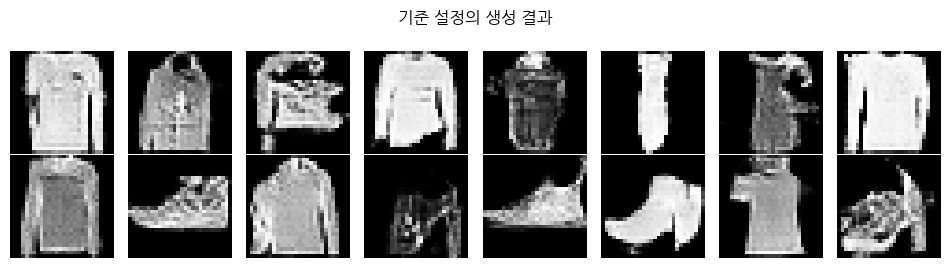

In [6]:

# 먼저 기준이 되는 본문 설정으로 학습(판별자에만 detach)
common.set_seed(SEED)
results['base'] = train_gan(Generator(LATENT_DIM).to(device), Discriminator().to(device),
                            train_loader, name='기준(본문 설정)',
                            detach_in_d=True, detach_in_g=False)
show_images(generate(results['base']['G'], 16, seed=SEED), title='기준 설정의 생성 결과')

In [7]:

# (1) 생성자 학습 단계에서 D(fake_images)를 D(fake_images.detach())로 바꾼 경우
#     기울기 흐름을 먼저 코드로 확인한다
G_probe = Generator(LATENT_DIM).to(device)
D_probe = Discriminator().to(device)
z = torch.randn(4, LATENT_DIM).to(device)

for label, detach in (('detach 없음(본문)', False), ('detach 적용', True)):
    G_probe.zero_grad()
    fake = G_probe(z)
    out = D_probe(fake.detach() if detach else fake)
    loss = criterion(out, torch.ones(4, 1).to(device))
    loss.backward()
    grads = [p.grad for p in G_probe.parameters() if p.grad is not None]
    total = sum(g.abs().sum().item() for g in grads)
    print(f'{label:<18} 생성자 기울기 텐서 {len(grads):>2}개, 절댓값 합 {total:.6f}')

detach 없음(본문)      생성자 기울기 텐서 10개, 절댓값 합 11246.879413
detach 적용          생성자 기울기 텐서  0개, 절댓값 합 0.000000


(1) 생성자 학습에도 detach 적용 학습


에포크  판별자 손실  생성자 손실     시간
  1/20       0.0150       8.2624     0:11


  2/20       0.0001      10.7381     0:22


  4/20       0.0000      12.3738     0:44


  6/20       0.0000      13.3247     1:06


...

 12/20       0.0000      15.2875     2:25


 14/20       0.0000      15.8612     2:49


 16/20       0.0000      16.3650     3:12


 18/20       0.0000      16.8953     3:35


 20/20       0.0000      17.4292     3:58
-----------------------------------------
전체 학습 시간 3:58


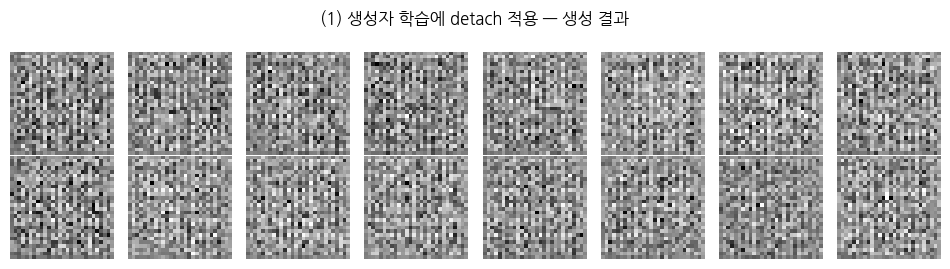

In [8]:

# (1) 실제로 학습해 본다
common.set_seed(SEED)
results['g_detach'] = train_gan(Generator(LATENT_DIM).to(device), Discriminator().to(device),
                                train_loader, name='(1) 생성자 학습에도 detach 적용',
                                detach_in_d=True, detach_in_g=True)
show_images(generate(results['g_detach']['G'], 16, seed=SEED),
            title='(1) 생성자 학습에 detach 적용 — 생성 결과')

(2) 판별자 학습에서 detach 제거 학습


에포크  판별자 손실  생성자 손실     시간
  1/20       0.7009       1.7801     0:12


  2/20       0.6907       1.6811     0:26


  4/20       0.9009       1.3078     0:50


  6/20       0.9779       1.2112     1:16


...

 12/20       1.0049       1.1914     2:42


 14/20       1.0099       1.1944     3:22


 16/20       1.0094       1.2098     3:52


 18/20       1.0109       1.2119     4:21


 20/20       1.0062       1.2156     4:44
-----------------------------------------
전체 학습 시간 4:44


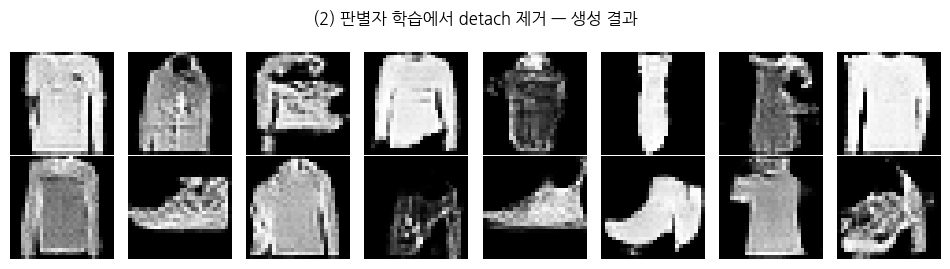

In [9]:

# (2) 판별자 학습 단계에서 detach를 제거한 경우
common.set_seed(SEED)
results['no_detach'] = train_gan(Generator(LATENT_DIM).to(device), Discriminator().to(device),
                                 train_loader, name='(2) 판별자 학습에서 detach 제거',
                                 detach_in_d=False, detach_in_g=False)
show_images(generate(results['no_detach']['G'], 16, seed=SEED),
            title='(2) 판별자 학습에서 detach 제거 — 생성 결과')

설정                                   판별자 손실(마지막)         생성자 손실(마지막)
----------------------------------------------------------------------
기준(본문 설정)                                 1.0062              1.2156
(1) 생성자에도 detach                          0.0000             17.4292
(2) 판별자에서 detach 제거                       1.0062              1.2156


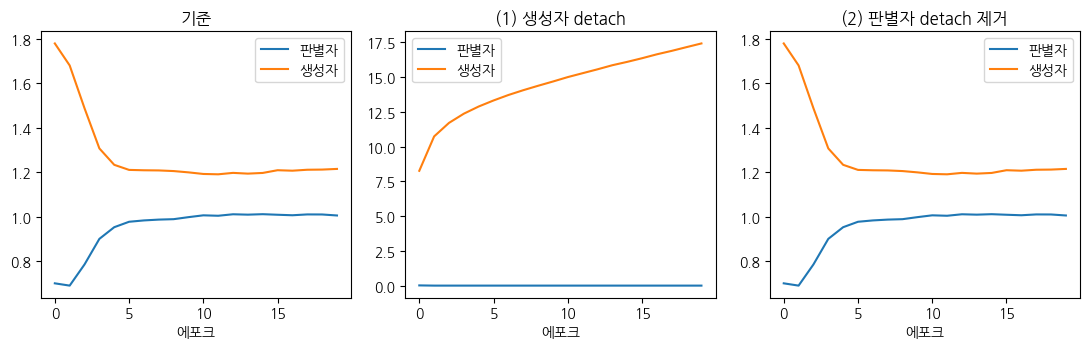

In [10]:

# 세 설정의 손실 추이 비교
print(f'{"설정":<28}{"판별자 손실(마지막)":>20}{"생성자 손실(마지막)":>20}')
print('-' * 70)
for key, name in (('base', '기준(본문 설정)'),
                  ('g_detach', '(1) 생성자에도 detach'),
                  ('no_detach', '(2) 판별자에서 detach 제거')):
    h = results[key]['log'].history
    print(f'{name:<28}{h["판별자 손실"][-1]:>20.4f}{h["생성자 손실"][-1]:>20.4f}')

plt.figure(figsize=(11, 3.6))
for i, (key, name) in enumerate((('base', '기준'), ('g_detach', '(1) 생성자 detach'),
                                 ('no_detach', '(2) 판별자 detach 제거')), 1):
    h = results[key]['log'].history
    plt.subplot(1, 3, i)
    plt.plot(h['판별자 손실'], label='판별자')
    plt.plot(h['생성자 손실'], label='생성자')
    plt.title(name)
    plt.xlabel('에포크')
    plt.legend()
plt.tight_layout()
plt.show()

### 풀이 해설 — 연습 문제 11-5

**`detach()`는 연산 그래프를 끊는 도구다.** 끊긴 지점 너머로는 기울기가 흐르지 않는다.
두 경우가 정반대의 결과를 낳는 이유가 여기 있다.

**(1) 생성자 학습 단계에서 `D(fake_images.detach())`로 바꾸면 — 생성자가 전혀 학습되지
않는다.**

생성자의 손실은 `criterion(D(fake_images), real_labels)`이다. 이 손실이 생성자까지
도달하려면 **판별자를 거쳐 가짜 이미지로, 다시 생성자로** 역전파가 흘러야 한다.
`fake_images`를 떼어 내면 그 경로가 끊긴다.

첫 셀의 기울기 측정이 이를 보여 준다. `detach`를 적용하면 **생성자 파라미터의 기울기가
하나도 만들어지지 않는다**(`p.grad`가 전부 `None`). `loss_g.backward()`와
`optim_g.step()`을 호출해도 갱신할 기울기가 없으므로 생성자는 **초기 무작위 파라미터
그대로 남는다.**

학습 곡선에서는 판별자 손실이 0에 가깝게 떨어지고 생성자 손실이 치솟는다. 판별자가
전혀 나아지지 않는 상대를 만나 쉽게 이기기 때문이다. 생성 결과는 무작위 노이즈에
가깝다. **오류 메시지가 나지 않는다는 점이 이 함정의 고약한 부분**이다. 조용히 학습이
안 될 뿐이다.

**(2) 판별자 학습 단계에서 `.detach()`를 제거하면 — 결과는 같지만 계산이 낭비된다.**

판별자 손실로 `backward()`를 부르면 **생성자까지 기울기가 계산된다.** 다만
`optim_d`는 `D.parameters()`만 갖고 있으므로 **생성자 파라미터가 갱신되지는 않는다.**
본문 p21이 "판별자 파라미터만 지정해 판별자 옵티마이저를 만들어도 생성자 파라미터가
갱신되지 않을 뿐 생성자까지 기울기 계산 과정에 동원된다"고 한 그대로다.

따라서 **학습 결과는 기준 설정과 거의 같고, 학습 시간만 늘어난다.** 생성자 쪽 역전파를
헛돌리기 때문이다.

**한 가지 주의할 점이 있다.** 이 경우 생성자에 쌓인 기울기가 지워지지 않은 채 남는다.
바로 다음 단계에서 `optim_g.zero_grad()`를 부르므로 이 예제에서는 문제가 되지 않지만,
순서를 바꾸거나 `zero_grad()`를 빠뜨리면 **판별자 학습에서 생긴 기울기가 생성자 갱신에
섞여 든다.** `detach()`를 쓰면 이런 사고 가능성 자체가 사라진다.

**정리하면 두 `detach()`의 성격이 다르다.**

| 위치 | 있으면 | 없으면 |
|---|---|---|
| 판별자 학습 (본문) | 불필요한 계산을 피한다 | 결과는 같지만 느리고, 기울기 오염 위험이 생긴다 |
| 생성자 학습 | **학습이 아예 안 된다** | 정상 |

**판별자 쪽은 효율과 안전의 문제이고, 생성자 쪽은 동작 여부의 문제다.**


## 연습 문제 11-6

In [11]:

# LATENT_DIM을 20, 100(본문), 200으로 바꿔 학습
for dim in (20, 200):
    common.set_seed(SEED)
    results[f'dim{dim}'] = train_gan(Generator(dim).to(device), Discriminator().to(device),
                                     train_loader, latent_dim=dim,
                                     name=f'LATENT_DIM {dim}')
    print()

results['dim100'] = results['base']

LATENT_DIM 20 학습


에포크  판별자 손실  생성자 손실     시간
  1/20       0.7170       1.6623     0:12


  2/20       0.8984       1.3095     0:23


  4/20       1.0906       1.0398     0:51


  6/20       1.1566       0.9681     1:18


...

 12/20       0.9733       1.2389     2:26


 14/20       0.9728       1.2604     2:51


 16/20       0.9596       1.2692     3:14


 18/20       0.9518       1.2786     3:39


 20/20       0.9507       1.3000     4:02
-----------------------------------------
전체 학습 시간 4:02



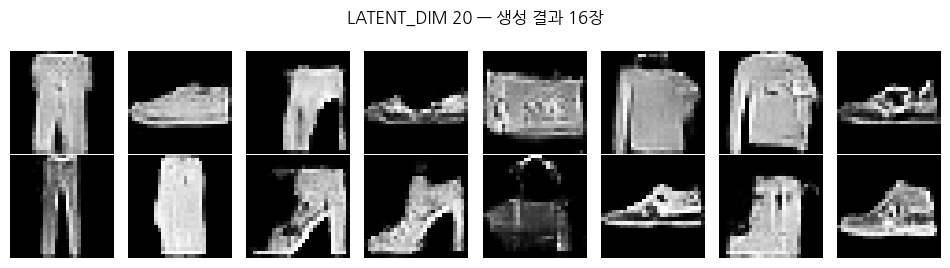

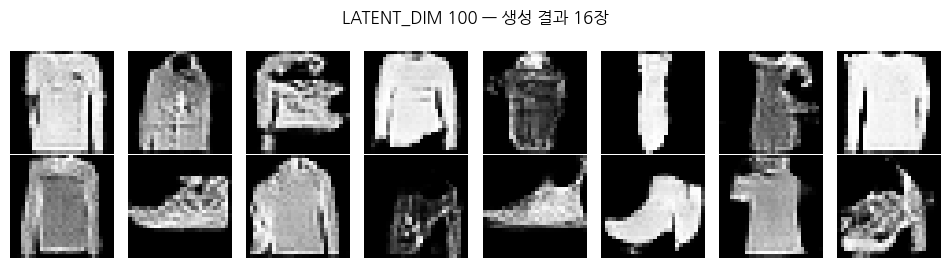

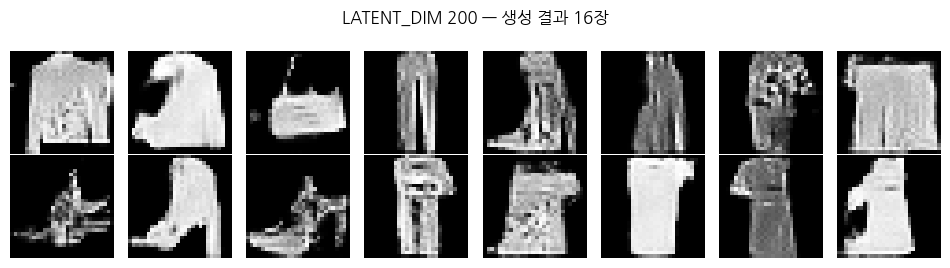

In [12]:

# 생성 결과 비교
for dim in (20, 100, 200):
    show_images(generate(results[f'dim{dim}']['G'], 16, latent_dim=dim, seed=SEED),
                title=f'LATENT_DIM {dim} — 생성 결과 16장')

In [13]:

# 다양성을 수치로: 생성 이미지 사이의 평균 거리와 클래스 분포
@torch.no_grad()
def diversity_stats(G, dim, n=500):
    imgs = generate(G, n, latent_dim=dim, seed=SEED)
    flat = imgs.view(n, -1)
    # 무작위 쌍 2,000개의 평균 L2 거리(클수록 서로 다른 이미지)
    idx_a = torch.randint(0, n, (2000,))
    idx_b = torch.randint(0, n, (2000,))
    dist = (flat[idx_a] - flat[idx_b]).pow(2).sum(1).sqrt()
    # 픽셀 단위 표준편차(생성 이미지 집합의 퍼짐)
    return dist.mean().item(), imgs.std().item()


print(f'{"LATENT_DIM":>12}{"평균 쌍 거리":>16}{"픽셀 표준편차":>16}'
      f'{"판별자 손실":>14}{"생성자 손실":>14}')
print('-' * 74)
for dim in (20, 100, 200):
    d, s = diversity_stats(results[f'dim{dim}']['G'], dim)
    h = results[f'dim{dim}']['log'].history
    print(f'{dim:>12}{d:>16.2f}{s:>16.4f}'
          f'{h["판별자 손실"][-1]:>14.4f}{h["생성자 손실"][-1]:>14.4f}')

  LATENT_DIM         평균 쌍 거리         픽셀 표준편차        판별자 손실        생성자 손실
--------------------------------------------------------------------------


          20           22.93          0.7141        1.1872        0.9634
         100           22.85          0.7059        1.0062        1.2156
         200           22.35          0.7012        0.9507        1.3000


### 풀이 해설 — 연습 문제 11-6

**잠재 벡터의 차원은 "생성자가 표현할 수 있는 이미지의 가짓수"를 정한다.**

**차원이 너무 작으면(20) 다양성이 부족하다.** Fashion-MNIST에는 열 가지 의류가 있고,
같은 클래스 안에서도 소매 길이나 굽 높이 같은 변화가 있다. 20차원으로 그 모든 변화를
담기에는 좁다. **서로 다른 잠재 벡터가 비슷한 이미지로 이어지는 일**이 잦아지고, 심하면
모드 붕괴(본문 p14 각주 6)로 이어진다.

**차원이 너무 크면(200) 다른 문제가 생긴다.** VAE와는 양상이 다르다는 점이 중요하다.

- VAE는 KL 발산이 잠재 공간을 표준 정규 분포로 끌어당기므로, 차원이 커지면
  **'그럴듯한 영역'의 비중이 줄어드는** 문제가 생겼다([연습 문제 11-1]).
- GAN에는 그런 제약이 없다. 생성자는 **표준 정규 분포에서 뽑은 벡터만** 입력으로 받도록
  학습되므로, 차원이 커져도 '빈틈'이라는 개념이 약하다. 대신 **생성자의 첫 선형 계층이
  커져 학습해야 할 파라미터가 늘고**, 잠재 공간의 여러 방향이 같은 이미지로 이어지는
  중복이 생긴다. 학습이 느려지고 불안정해지기 쉽다.

**그래서 GAN에서 차원을 키우는 것은 VAE만큼 위험하지 않다.** DCGAN 논문이 100을 쓴
이후 많은 구현이 그대로 따르는데, 이 예제 규모에서는 100 안팎이면 충분하다는 뜻이다.
200으로 늘려도 눈에 띄게 나빠지지 않는다면 그것도 타당한 관찰이다.

**다양성을 눈으로만 판단하기 어려우므로 수치를 함께 봤다.** 생성 이미지 쌍의 평균 거리가
작으면 비슷한 이미지만 만들고 있다는 뜻이고, 픽셀 표준편차가 작으면 이미지 집합 전체가
밋밋하다는 뜻이다. **16장만 보고 판단하면 우연에 휘둘리기 쉽다.**

**손실값으로는 판단할 수 없다는 점도 기억해 둘 만하다.** 본문 p22가 말한 대로 GAN의
손실은 경쟁의 균형을 보여 줄 뿐 품질을 보여 주지 않는다. 모드 붕괴가 일어나도 손실은
멀쩡해 보일 수 있다.


## 연습 문제 11-7

[연습 문제 11-4]와 같은 데이터셋 문제가 있다. CelebA는 `torchvision` 자동
다운로드가 어렵고 `LFWPeople`은 자동 다운로드가 중단되었으므로, 여기서도 **CelebA를
시도한 뒤 실패하면 CIFAR-10으로 대체**한다.

한 가지 더 생각할 점이 있다. **GAN에는 인코더가 없다.** 본문 p22가 "판별자는 진짜와
가짜를 판단하는 역할일 뿐 이미지를 잠재 벡터로 인코딩하는 인코더가 아니다"라고
밝힌 대로다. 따라서 VAE처럼 '두 이미지를 인코딩해 그 사이를 보간'할 수 없고,
**두 잠재 벡터를 먼저 만들고 그 사이를 보간해 두 이미지를 얻는** 순서가 된다.

In [14]:

# 컬러 데이터셋 준비([-1, 1] 정규화)
from torchvision.datasets import CIFAR10

IMG_SIZE = 32
color_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

try:
    from torchvision.datasets import CelebA
    color_set = CelebA(root=data_root, split='train', download=True,
                       transform=color_transform)
    color_name = 'CelebA(얼굴)'
except Exception as e:
    print(f'CelebA를 사용할 수 없어 CIFAR-10으로 대체한다: {type(e).__name__}')
    color_set = CIFAR10(root=data_root, train=True, download=True,
                        transform=color_transform)
    color_name = 'CIFAR-10(컬러 대체)'

color_loader = DataLoader(color_set, batch_size=BATCH_SIZE, shuffle=True)
print(f'{color_name}: {len(color_set):,}장, 샘플 형태 {tuple(color_set[0][0].shape)}')

CelebA를 사용할 수 없어 CIFAR-10으로 대체한다: RuntimeError


CIFAR-10(컬러 대체): 50,000장, 샘플 형태 (3, 32, 32)


In [15]:

# 컬러 이미지용 생성자와 판별자(채널 3, 해상도 32x32)
class ColorGenerator(nn.Module):
    def __init__(self, latent_dim=100, channels=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.fc_z_to_fmap = nn.Sequential(
            nn.Linear(latent_dim, 256 * 4 * 4),
            nn.BatchNorm1d(256 * 4 * 4),
            nn.ReLU(),
        )
        self.gen_conv = nn.Sequential(                    # (256, 4, 4) -> (3, 32, 32)
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),               # (128, 8, 8)
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),                # (64, 16, 16)
            nn.ConvTranspose2d(64, channels, 4, stride=2, padding=1),
            nn.Tanh(),                                    # (3, 32, 32)
        )

    def forward(self, z):
        h = self.fc_z_to_fmap(z).view(z.size(0), 256, 4, 4)
        return self.gen_conv(h)


class ColorDiscriminator(nn.Module):
    def __init__(self, channels=3):
        super().__init__()
        self.disc_conv = nn.Sequential(                   # (3, 32, 32) -> (256, 4, 4)
            nn.Conv2d(channels, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),                            # 첫 블록에는 배치 정규화 없음
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(256 * 4 * 4, 1), nn.Sigmoid())

    def forward(self, x):
        return self.fc(self.disc_conv(x))


common.set_seed(SEED)
results['color'] = train_gan(ColorGenerator(LATENT_DIM).to(device),
                             ColorDiscriminator().to(device),
                             color_loader, epochs=20,
                             name=f'컬러 DCGAN({color_name})')

컬러 DCGAN(CIFAR-10(컬러 대체)) 학습


에포크  판별자 손실  생성자 손실     시간
  1/20       0.3572       4.7626     0:14


  2/20       0.3921       4.2721     0:27


  4/20       0.5636       2.9290     0:54


  6/20       0.4851       2.9076     1:21


...

 12/20       0.6598       2.2433     2:40


 14/20       0.6063       2.2731     3:09


 16/20       0.6491       2.2406     3:36


 18/20       0.6059       2.2023     4:02


 20/20       0.6250       2.2957     4:28
-----------------------------------------
전체 학습 시간 4:28


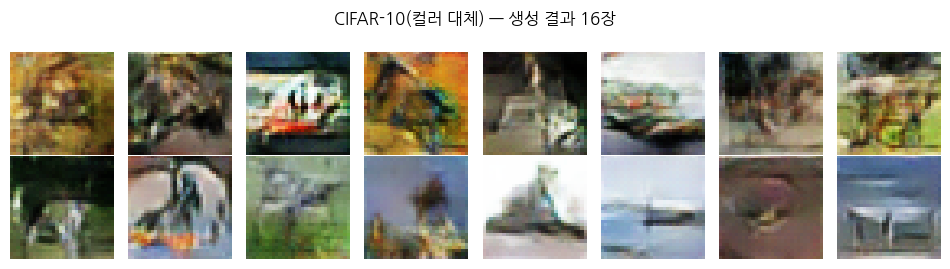

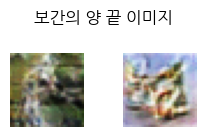

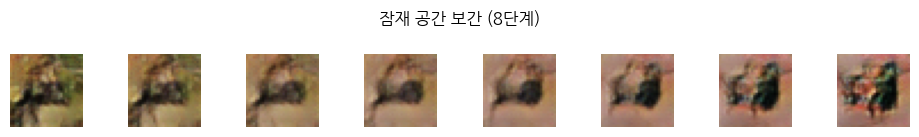

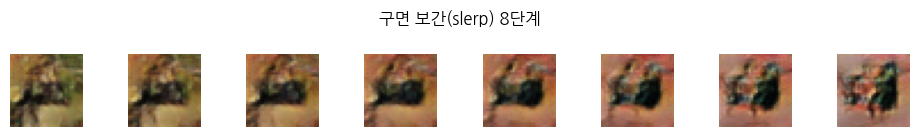

In [16]:

# 생성 결과와 잠재 공간 보간
G_color = results['color']['G']
show_images(generate(G_color, 16, seed=SEED), title=f'{color_name} — 생성 결과 16장')


@torch.no_grad()
def interpolate_gan(G, z_a, z_b, steps=8):
    """GAN에는 인코더가 없으므로 잠재 벡터 사이를 직접 보간한다."""
    G.eval()
    alphas = torch.linspace(0, 1, steps).to(device).view(-1, 1)
    zs = (1 - alphas) * z_a + alphas * z_b
    out = G(zs)
    G.train()
    return out


common.set_seed(SEED)
z_a = torch.randn(1, LATENT_DIM).to(device)
z_b = torch.randn(1, LATENT_DIM).to(device)
show_images(G_color(torch.cat([z_a, z_b])), n_cols=2, title='보간의 양 끝 이미지')
show_images(interpolate_gan(G_color, z_a, z_b), n_cols=8, title='잠재 공간 보간 (8단계)')

# 구면 보간(slerp): 표준 정규 분포의 성질을 지키며 보간하는 방법
@torch.no_grad()
def slerp(G, z_a, z_b, steps=8):
    a = z_a / z_a.norm()
    b = z_b / z_b.norm()
    omega = torch.acos((a * b).sum().clamp(-1, 1))
    alphas = torch.linspace(0, 1, steps).to(device).view(-1, 1)
    zs = (torch.sin((1 - alphas) * omega) * z_a
          + torch.sin(alphas * omega) * z_b) / torch.sin(omega)
    G.eval()
    out = G(zs)
    G.train()
    return out


show_images(slerp(G_color, z_a, z_b), n_cols=8, title='구면 보간(slerp) 8단계')

### 풀이 해설 — 연습 문제 11-7

**VAE의 보간과 결정적으로 다른 점이 하나 있다. 출발점을 정하는 방법이다.**

VAE는 **주어진 이미지를 인코딩**해 잠재 벡터를 얻었다. GAN에는 인코더가 없으므로 그렇게
할 수 없다. 대신 **잠재 벡터를 먼저 뽑고 그것으로 이미지를 만든 다음**, 두 잠재 벡터
사이를 보간한다. 순서가 반대다.

그래서 "**임의의 두 사람의 얼굴 이미지를 만든 후**"라는 지문의 표현이 정확하다. 기존
사진 두 장을 고르는 것이 아니라 **생성한 두 장** 사이를 잇는다.

**여기서 선형 보간의 함정이 드러난다.** 잠재 벡터는 표준 정규 분포에서 뽑는다.
고차원에서 표준 정규 분포를 따르는 벡터의 길이는 대략 `√d`(100차원이면 10 안팎)에
몰려 있다. 그런데 두 벡터를 **선형 보간**하면 중간 지점의 길이가 짧아진다. 두 벡터가
서로 다른 방향을 가리킬수록 더 짧아진다.

즉 **보간 중간의 잠재 벡터는 생성자가 학습 중에 본 적 없는 '짧은' 벡터**가 되고,
그 결과 중간 이미지가 흐릿하거나 평균적인 모습으로 무너진다.

**구면 보간(slerp)이 이 문제를 푼다.** 직선이 아니라 구면을 따라 이동해 **길이를
유지한 채** 방향만 바꾼다. 마지막 셀에서 두 방법을 나란히 그렸는데, **중간 단계의
선명도 차이**가 이 설명의 확인이다. GAN 보간에서는 slerp가 사실상 표준이다.

VAE에서 선형 보간이 잘 동작한 이유도 함께 생각해 볼 만하다. VAE는 **실제 이미지를
인코딩한 `mu` 사이를 잇는다.** 두 `mu`는 모두 학습 데이터가 차지한 영역 안에 있고,
KL 발산이 그 영역을 촘촘히 채워 두었으므로 직선 경로도 대체로 학습된 영역 안에 머문다.

**컬러로 확장하며 바꾼 것**은 [연습 문제 11-4]와 같다. 입출력 채널을 3으로, 특징 지도
시작 크기를 `7x7`에서 `4x4`로 바꾸고 역합성곱을 한 단계 더 두어 32까지 키웠다
(`4 → 8 → 16 → 32`). 판별자도 대칭으로 한 단계 깊게 했다. **첫 합성곱 블록에 배치
정규화를 두지 않는 규칙**(본문 p17)은 그대로 지켰다.


## 연습 문제 11-8 [도전 문제]

In [17]:

# 선형 계층 대신 역합성곱으로 잠재 벡터를 특징 지도로 펼치는 생성자
class GeneratorNoLinear(nn.Module):
    """잠재 벡터를 (latent_dim, 1, 1) 형태로 보고 역합성곱으로 7x7까지 키운다.

    클래스 이름에 Conv를 넣지 않은 이유가 있다. [코드 11-9]의 weights_init()은
    m.__class__.__name__ 에 'Conv'가 들어 있으면 합성곱 계층으로 보고
    m.weight 를 건드리는데, 모델 클래스 이름에 Conv가 들어가면 모델 자신도
    합성곱 계층으로 오인되어 AttributeError 가 난다.
    """

    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim
        self.gen_conv = nn.Sequential(
            # (latent_dim, 1, 1) -> (256, 7, 7): kernel 7, stride 1, padding 0
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),               # (128, 14, 14)
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),                                    # (1, 28, 28)
        )

    def forward(self, z):
        h = z.view(z.size(0), self.latent_dim, 1, 1)      # 선형 계층 대신 형태만 바꿈
        return self.gen_conv(h)


common.set_seed(SEED)
results['conv_expand'] = train_gan(GeneratorNoLinear(LATENT_DIM).to(device),
                                   Discriminator().to(device), train_loader,
                                   name='역합성곱 확장 생성자')

역합성곱 확장 생성자 학습


에포크  판별자 손실  생성자 손실     시간
  1/20       0.7982       1.5632     0:11


  2/20       0.9841       1.1980     0:22


  4/20       1.1780       0.9603     0:44


  6/20       1.1985       0.9421     1:06


...

 12/20       1.2483       0.8903     2:12


 14/20       1.2529       0.8851     2:34


 16/20       1.2558       0.8814     2:56


 18/20       1.2516       0.8879     3:18


 20/20       1.2503       0.8905     3:40
-----------------------------------------
전체 학습 시간 3:40


생성자 구조                         전체 파라미터          확장 계층 파라미터
------------------------------------------------------------
선형 계층(본문)                    1,818,753           1,292,032
역합성곱                         1,781,889           1,254,656

확장 계층 파라미터 비: 1.0배


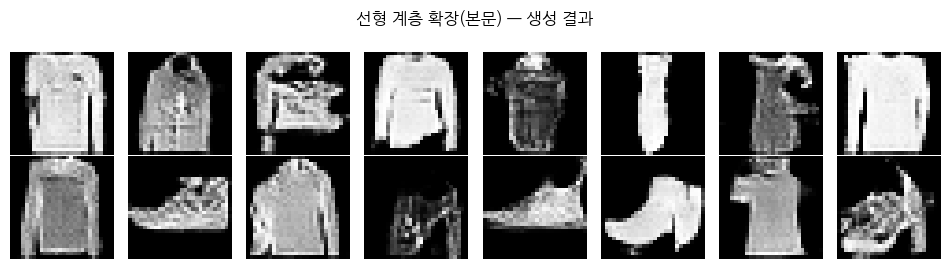

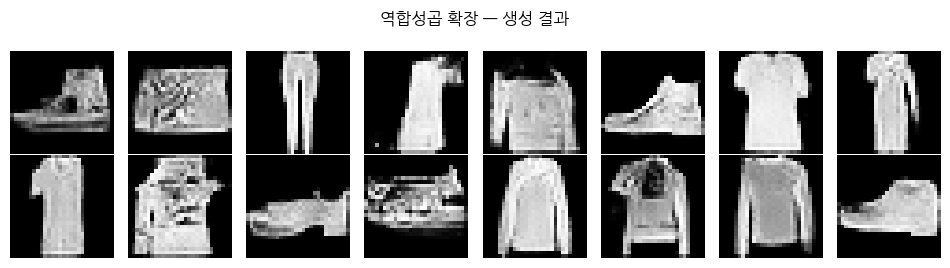

구조                            판별자 손실        생성자 손실
--------------------------------------------------
선형 계층(본문)                     1.0062        1.2156
역합성곱                          1.2503        0.8905


In [18]:

# 구조와 결과 비교
g_linear = results['base']['G']
g_conv = results['conv_expand']['G']

print(f'{"생성자 구조":<22}{"전체 파라미터":>16}{"확장 계층 파라미터":>20}')
print('-' * 60)
lin_expand = sum(p.numel() for p in g_linear.fc_z_to_fmap.parameters())
conv_expand = sum(p.numel() for p in g_conv.gen_conv[0].parameters())
print(f'{"선형 계층(본문)":<22}{sum(p.numel() for p in g_linear.parameters()):>16,}'
      f'{lin_expand:>20,}')
print(f'{"역합성곱":<22}{sum(p.numel() for p in g_conv.parameters()):>16,}'
      f'{conv_expand:>20,}')
print(f'\n확장 계층 파라미터 비: {lin_expand / conv_expand:.1f}배')

show_images(generate(g_linear, 16, seed=SEED), title='선형 계층 확장(본문) — 생성 결과')
show_images(generate(g_conv, 16, seed=SEED), title='역합성곱 확장 — 생성 결과')

print(f'{"구조":<22}{"판별자 손실":>14}{"생성자 손실":>14}')
print('-' * 50)
for key, name in (('base', '선형 계층(본문)'), ('conv_expand', '역합성곱')):
    h = results[key]['log'].history
    print(f'{name:<22}{h["판별자 손실"][-1]:>14.4f}{h["생성자 손실"][-1]:>14.4f}')

### 풀이 해설 — 연습 문제 11-8

**두 방식은 '잠재 벡터를 어떻게 공간으로 펼치는가'에서 갈린다.**

**선형 계층 방식(본문)** — `Linear(100, 256*7*7)`로 한 번에 펼친다. 잠재 벡터의 모든
성분이 12,544개 출력 전부에 영향을 준다. **완전 연결이므로 위치에 대한 제약이 없다.**

**역합성곱 방식** — 잠재 벡터를 `(100, 1, 1)` 형태, 즉 **1x1 크기에 100채널인 특징
지도**로 보고 `kernel_size=7, stride=1, padding=0`인 역합성곱으로 `(256, 7, 7)`까지
키운다. DCGAN 원 논문이 쓴 방식이 이쪽이다.

**파라미터 수가 결정적으로 다르다.**

- 선형 계층: `100 × 12,544 + 12,544` ≈ **125만 개**
- 역합성곱: `100 × 256 × 7 × 7 + 256` ≈ **125만 개**

계산해 보면 **거의 같다.** `kernel_size=7`인 역합성곱이 사실상 `1x1 → 7x7` 완전 연결과
같은 일을 하기 때문이다. 이 지점이 이 문제의 핵심이다. **두 방식은 파라미터 수로는
구분되지 않는다.** 차이는 다른 데 있다.

**첫째, 배치 정규화의 위치와 성격이 다르다.** 선형 방식은 `BatchNorm1d(12544)`로
12,544개 값을 **각각 따로** 정규화한다. 역합성곱 방식은 `BatchNorm2d(256)`로 **채널
단위**로 정규화하므로, 같은 채널 안의 49개 위치가 통계를 공유한다. **공간적 일관성이
구조에 들어 있는 셈**이다.

**둘째, 확장 규모를 바꾸기 쉽다.** 해상도를 키우려면 선형 방식은 출력 크기를 다시
계산해야 하지만, 역합성곱 방식은 `kernel_size`만 바꾸면 된다. [연습 문제 11-7]처럼
컬러·고해상도로 옮길 때 이 차이가 드러난다.

**셋째, `view()` 호출이 사라진다.** 선형 방식은 `h.view(h.size(0), 256, 7, 7)`로 모양을
손으로 바꿔 줘야 하는데, 역합성곱 방식은 입력을 `(latent_dim, 1, 1)`로 보는 것 외에
형태 조작이 없다. 사소해 보이지만 **모양 계산 실수가 줄어드는** 실질적 이점이다.

**생성 품질 차이는 크지 않은 것이 정상이다.** 하는 일이 사실상 같기 때문이다. 이
문제의 값어치는 "성능이 더 좋아지는 구조를 찾는 것"이 아니라, **같은 연산을 다른
방식으로 표현할 수 있고 그때 무엇이 달라지는지 아는 것**에 있다.

`FashionVAE`의 `fc_z_to_fmap`도 같은 방식으로 바꿀 수 있다. 다만 VAE는 **인코더가
`fc_mu`, `fc_log_var`로 평탄화된 벡터를 다루므로** 디코더만 역합성곱으로 바꾸면 두
방향의 구조가 비대칭이 된다. 대칭을 맞추려면 인코더 쪽도 함께 손봐야 한다.


## 연습 문제 11-9 [도전 문제]

### (1) 무엇을 바꿔야 cGAN이 되는가

DCGAN을 cGAN으로 바꾸려면 **생성자와 판별자 양쪽이 '어떤 클래스인지'를 알아야 한다.**
바꿀 곳은 네 군데다.

**하나, 생성자 입력.** 잠재 벡터만 받던 것을 **잠재 벡터 + 클래스 정보**로 바꾼다.
클래스 레이블은 정수이므로 그대로 이어 붙일 수 없고, 임베딩 계층으로 벡터로 바꾼 뒤
잠재 벡터와 이어 붙인다. 10장에서 토큰을 임베딩으로 바꾼 것과 같은 방식이다.

**둘, 판별자 입력.** 이미지만 받던 것을 **이미지 + 클래스 정보**로 바꾼다. 이미지는
`(1, 28, 28)` 형태이므로 클래스 벡터를 그대로 붙일 수 없다. 클래스마다 하나의 채널을
만들어 **이미지에 채널로 덧붙이는** 방법이 흔하다(`(1 + 10, 28, 28)`).

**셋, 학습 루프.** 데이터로더가 주는 레이블을 버리지 않고 쓴다. 본문 [코드 11-11]의
`for real_images, _ in train_loader:`에서 `_`로 버린 것이 바로 그 레이블이다. 가짜
이미지를 만들 때도 **무작위 클래스 레이블을 함께 뽑아** 생성자와 판별자에 전달한다.

**넷, 판별자가 배워야 할 것이 하나 늘어난다.** 기존 판별자는 '진짜인가'만 봤지만,
cGAN의 판별자는 **'진짜이면서 주어진 클래스에 맞는가'**를 본다. 레이블이 어긋난 진짜
이미지도 가짜로 판정하도록 학습시키면 조건 제어가 더 분명해진다(이 풀이는 기본형을
따라 그렇게까지 하지는 않는다).

In [19]:

# (2) cGAN 구현
NUM_CLASSES = 10
CLASS_EMB_DIM = 50


class CGenerator(nn.Module):
    """잠재 벡터와 클래스 임베딩을 이어 붙여 입력으로 사용하는 생성자"""

    def __init__(self, latent_dim=100, num_classes=NUM_CLASSES,
                 class_emb_dim=CLASS_EMB_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.label_embedding = nn.Embedding(num_classes, class_emb_dim)
        self.fc_z_to_fmap = nn.Sequential(
            nn.Linear(latent_dim + class_emb_dim, 256 * 7 * 7),
            nn.BatchNorm1d(256 * 7 * 7),
            nn.ReLU(),
        )
        self.gen_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 1, 4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        # 잠재 벡터와 클래스 임베딩을 이어 붙인다
        h = torch.cat([z, self.label_embedding(labels)], dim=1)
        h = self.fc_z_to_fmap(h).view(z.size(0), 256, 7, 7)
        return self.gen_conv(h)


class CDiscriminator(nn.Module):
    """클래스를 채널로 덧붙인 이미지를 입력으로 사용하는 판별자"""

    def __init__(self, num_classes=NUM_CLASSES, img_size=28):
        super().__init__()
        self.num_classes = num_classes
        self.img_size = img_size
        self.disc_conv = nn.Sequential(
            # 입력 채널이 1에서 1 + num_classes로 늘어난다
            nn.Conv2d(1 + num_classes, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
        )
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(128 * 7 * 7, 1), nn.Sigmoid())

    def forward(self, x, labels):
        # 클래스를 원-핫으로 바꿔 이미지와 같은 크기의 채널로 펼친다
        one_hot = torch.zeros(x.size(0), self.num_classes, device=x.device)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)
        label_map = one_hot.view(x.size(0), self.num_classes, 1, 1)
        label_map = label_map.expand(-1, -1, self.img_size, self.img_size)
        return self.fc(self.disc_conv(torch.cat([x, label_map], dim=1)))

In [20]:

# cGAN 학습 함수(본문 [코드 11-11]에 레이블 전달을 더한 것)
def train_epoch_cgan(G, D, loader, optim_g, optim_d, criterion, latent_dim, device):
    G.train()
    D.train()
    total_loss_d = total_loss_g = 0.0
    total_samples = 0
    for real_images, real_class in loader:
        real_images = real_images.to(device)
        real_class = real_class.to(device)          # 본문에서 _로 버리던 레이블
        batch_size = real_images.size(0)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ① 판별자 학습
        optim_d.zero_grad()
        loss_d_real = criterion(D(real_images, real_class), real_labels)
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_class = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)
        fake_images = G(z, fake_class)
        loss_d_fake = criterion(D(fake_images.detach(), fake_class), fake_labels)
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optim_d.step()

        # ② 생성자 학습
        optim_g.zero_grad()
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_class = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)
        fake_images = G(z, fake_class)
        loss_g = criterion(D(fake_images, fake_class), real_labels)
        loss_g.backward()
        optim_g.step()

        total_loss_d += loss_d.item() * batch_size
        total_loss_g += loss_g.item() * batch_size
        total_samples += batch_size
    return total_loss_d / total_samples, total_loss_g / total_samples


common.set_seed(SEED)
results['cgan'] = train_gan(CGenerator(LATENT_DIM).to(device),
                            CDiscriminator().to(device), train_loader,
                            epochs=20, name='cGAN', train_fn=train_epoch_cgan)

cGAN 학습


에포크  판별자 손실  생성자 손실     시간
  1/20       0.9654       1.2947     0:12


  2/20       0.8745       1.3767     0:25


  4/20       1.0711       1.2224     0:48


  6/20       1.1394       1.0883     1:12


...

 12/20       1.2365       0.9542     2:21


 14/20       1.2475       0.9363     2:43


 16/20       1.2598       0.9314     3:07


 18/20       1.2663       0.9231     3:30


 20/20       1.2677       0.9076     3:54
-----------------------------------------
전체 학습 시간 3:54


클래스 이름: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


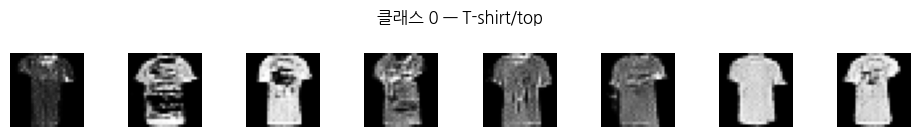

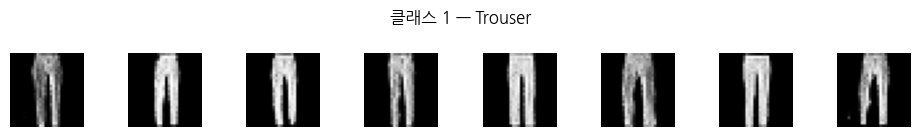

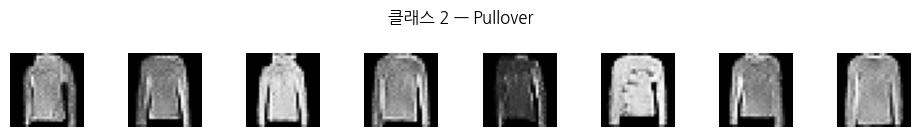

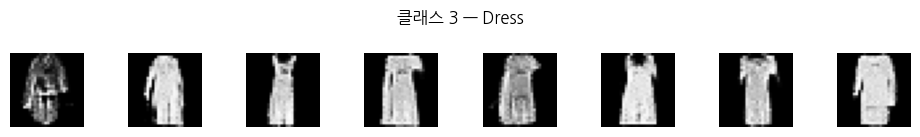

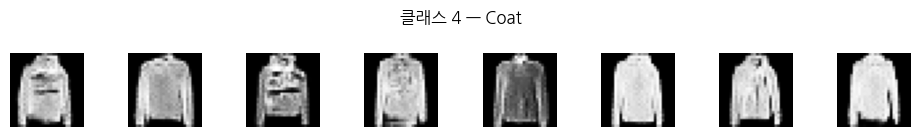

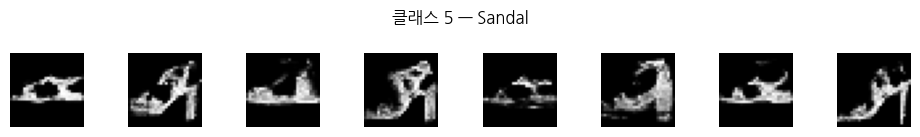

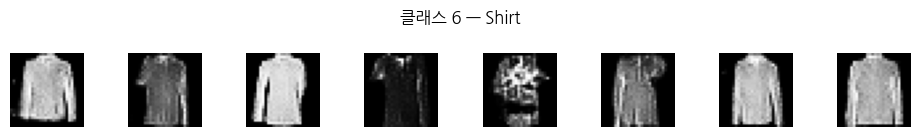

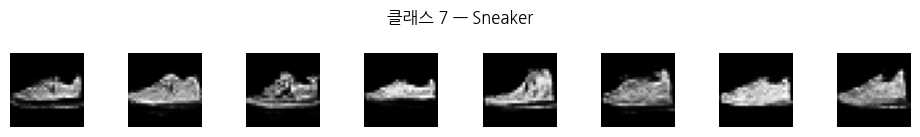

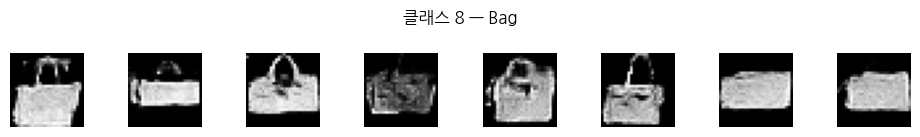

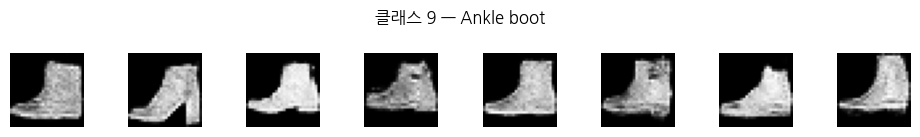

CGenerator(
  (label_embedding): Embedding(10, 50)
  (fc_z_to_fmap): Sequential(
    (0): Linear(in_features=150, out_features=12544, bias=True)
    (1): BatchNorm1d(12544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (gen_conv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)

In [21]:

# 원하는 클래스의 이미지를 생성해 본다
print('클래스 이름:', train_set.classes)

G_c = results['cgan']['G']
G_c.eval()
common.set_seed(SEED)
with torch.no_grad():
    # 각 클래스마다 8장씩 생성
    for cls in range(NUM_CLASSES):
        z = torch.randn(8, LATENT_DIM).to(device)
        labels = torch.full((8,), cls, dtype=torch.long, device=device)
        show_images(G_c(z, labels), n_cols=8,
                    title=f'클래스 {cls} — {train_set.classes[cls]}')
G_c.train()

In [22]:

# 조건이 실제로 지켜지는지 분류기로 확인
class FashionClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(64 * 7 * 7, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


# 분류기는 [-1, 1] 입력에 맞춰 같은 정규화로 학습한다
common.set_seed(SEED)
clf = FashionClassifier().to(device)
clf_opt = optim.Adam(clf.parameters(), lr=1e-3)
clf_crit = nn.CrossEntropyLoss()
print('조건 확인용 분류기 학습')
clf_log = common.EpochLogger(5, columns=('훈련 손실',), formats=('{:.4f}',), target_rows=5)
for epoch in range(1, 6):
    clf.train()
    tot = n = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        clf_opt.zero_grad()
        loss = clf_crit(clf(images), labels)
        loss.backward()
        clf_opt.step()
        tot += loss.item() * images.size(0)
        n += images.size(0)
    clf_log.row(epoch, tot / n)
clf_log.summary()

# 클래스별로 100장씩 생성해 분류 결과와 비교
G_c.eval()
clf.eval()
common.set_seed(SEED)
print()
print(f'{"지정 클래스":<16}{"분류 일치율":>12}{"가장 많이 나온 예측":>22}')
print('-' * 52)
hits = 0
with torch.no_grad():
    for cls in range(NUM_CLASSES):
        z = torch.randn(100, LATENT_DIM).to(device)
        labels = torch.full((100,), cls, dtype=torch.long, device=device)
        pred = clf(G_c(z, labels)).argmax(1)
        match = (pred == cls).float().mean().item() * 100
        hits += (pred == cls).sum().item()
        top = torch.bincount(pred, minlength=NUM_CLASSES).argmax().item()
        print(f'{train_set.classes[cls]:<16}{match:>11.1f}%{train_set.classes[top]:>22}')
print(f'\n전체 조건 일치율: {hits / (NUM_CLASSES * 100) * 100:.1f}%')
G_c.train()

조건 확인용 분류기 학습


에포크    훈련 손실     시간
   1/5       0.4348     0:09


   2/5       0.3080     0:17


   3/5       0.2774     0:25


   4/5       0.2532     0:34


   5/5       0.2390     0:42
----------------------------
전체 학습 시간 0:42

지정 클래스                분류 일치율           가장 많이 나온 예측
----------------------------------------------------
T-shirt/top            84.0%           T-shirt/top
Trouser               100.0%               Trouser
Pullover               89.0%              Pullover
Dress                  97.0%                 Dress
Coat                   70.0%                  Coat
Sandal                 99.0%                Sandal
Shirt                  85.0%                 Shirt
Sneaker                99.0%               Sneaker
Bag                   100.0%                   Bag
Ankle boot             90.0%            Ankle boot

전체 조건 일치율: 91.3%


CGenerator(
  (label_embedding): Embedding(10, 50)
  (fc_z_to_fmap): Sequential(
    (0): Linear(in_features=150, out_features=12544, bias=True)
    (1): BatchNorm1d(12544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (gen_conv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)

### 풀이 해설 — 연습 문제 11-9

**cGAN의 발상은 단순하다. 생성자와 판별자 양쪽에 같은 조건을 알려 주는 것이다.**
한쪽만 알면 균형이 깨진다.

- **생성자만 알면** 판별자는 조건을 모르므로 '진짜 같은가'만 본다. 생성자는 조건을
  무시하고 판별자를 속이기 쉬운 이미지만 만들어도 손해를 보지 않는다. **조건이
  학습되지 않는다.**
- **판별자만 알면** 생성자는 무엇을 만들어야 할지 모른 채 혼나기만 한다. 학습이
  무너진다.

**조건을 넣는 방법이 두 신경망에서 다른 것**이 구현의 요점이다.

**생성자** — 입력이 `(latent_dim,)` 벡터이므로 클래스도 벡터로 만들어 **이어 붙인다.**
임베딩 계층을 쓰는 이유는 10장에서 토큰을 다룰 때와 같다. 정수 레이블을 그대로 넣으면
'클래스 7이 클래스 1보다 7배 크다'는 잘못된 관계가 생기고, 원-핫은 학습 가능한 표현이
아니다. **임베딩은 클래스 사이의 관계를 스스로 배운다.**

**판별자** — 입력이 `(1, 28, 28)` 이미지이므로 벡터를 이어 붙일 수 없다. 이 풀이는
클래스를 원-핫으로 바꾼 뒤 **이미지와 같은 크기의 채널 10장으로 펼쳐** 덧붙였다.
입력 채널이 1에서 11로 늘어나므로 첫 합성곱의 `in_channels`도 함께 바꿔야 한다.
**흔한 실수 지점**이다.

다른 방법도 있다. 판별자의 합성곱을 통과한 뒤 평탄화된 벡터에 클래스 임베딩을 이어
붙이는 방식인데, 구현은 간단하지만 **클래스 정보가 합성곱을 거치지 않아** 조건 제어가
약해지는 경향이 있다.

**학습 루프에서 바뀌는 것은 한 줄 반이다.** 본문 [코드 11-11]의
`for real_images, _ in train_loader:`에서 `_`를 `real_class`로 바꿔 받고, 가짜 이미지를
만들 때 `fake_class`를 무작위로 뽑아 생성자와 판별자에 함께 넘긴다. **`detach()`의
위치와 번갈아 학습하는 구조는 그대로다.**

**조건이 지켜지는지 눈으로만 판단하기 어려우므로 분류기로 확인했다.** [연습 문제 11-2]에서
쓴 방법을 그대로 가져와, 클래스마다 100장씩 생성한 뒤 분류기가 그 클래스로 맞히는
비율을 잰다. 이 비율이 높으면 조건 제어가 동작한다는 뜻이다.

**클래스별로 성적이 갈리는 것이 관전 포인트다.** Fashion-MNIST에는 서로 닮은 클래스가
있다(티셔츠·풀오버·코트·셔츠는 모두 상의다). **닮은 클래스끼리 헷갈리는 패턴**이
나온다면, 그것은 cGAN의 실패라기보다 **데이터 자체의 모호함**이다. 분류기의 예측을
'가장 많이 나온 예측'과 함께 출력한 이유가 여기 있다. 어느 클래스로 새는지 보면
원인을 가늠할 수 있다.


---

## 정리

11-2절의 다섯 문제는 DCGAN을 세 방향으로 살펴본다.

- **기울기 흐름의 이해(11-5)** — `detach()` 한 줄의 위치가 '효율 문제'와 '동작 여부
  문제'로 갈린다. GAN처럼 두 신경망이 얽힌 구조에서 연산 그래프를 읽는 훈련이다.
- **하이퍼파라미터와 구조(11-6, 11-8)** — 잠재 차원과 확장 계층의 선택. 둘 다
  **성능이 크게 달라지지 않는 것이 정상**이며, 무엇과 무엇을 맞바꾸는지 설명할 수
  있으면 된다.
- **확장(11-7, 11-9)** — 컬러·고해상도로 넓히고, 조건을 붙여 제어한다. 11-9의 cGAN은
  본문 마지막 문단이 예고한 내용을 직접 만들어 보는 문제다.

[연습 문제 11-7]의 보간은 11-1절 [연습 문제 11-4]와 짝을 이루는데, **GAN에는 인코더가
없어 보간의 출발점을 정하는 방법이 다르다**는 점이 두 문제를 가른다.
